In [4]:
%matplotlib inline

import torch
from torch import nn
from d2l import torch as d2l

# 실제로 수렴을 결정하는 것은 Learning Rate만이 아니라 Learning Rate와 Curvature의 곱

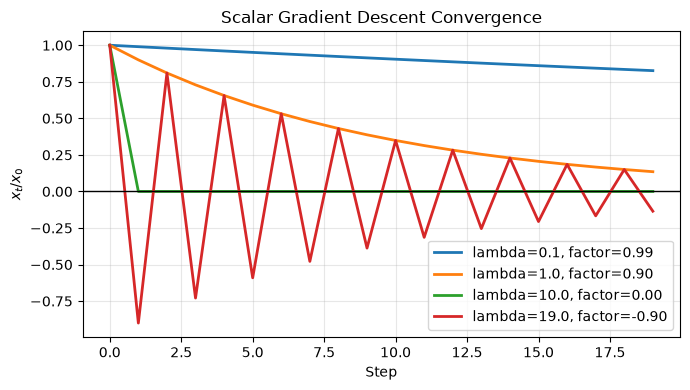

In [5]:
# Scalar Function:
# f(x) = (lambda / 2) * x^2
#
# Gradient Descent:
# x_t = (1 - eta * lambda)^t * x_0

curvature_values = [
    0.1,
    1.0,
    10.0,
    19.0,
]

learning_rate = 0.1
num_steps = 20

steps = torch.arange(
    num_steps,
    dtype=torch.float32,
)

figure, axis = d2l.plt.subplots(
    figsize=(7, 4),
)

for curvature in curvature_values:
    contraction_factor = (
        1.0 - learning_rate * curvature
    )

    normalized_parameters = torch.pow(
        torch.tensor(
            contraction_factor,
            dtype=torch.float32,
        ),
        steps,
    )

    axis.plot(
        steps.numpy(),
        normalized_parameters.numpy(),
        linewidth=2,
        label=(
            f"lambda={curvature:.1f}, "
            f"factor={contraction_factor:.2f}"
        ),
    )

axis.axhline(
    y=0.0,
    color="black",
    linewidth=1,
)

axis.set_xlabel("Step")
axis.set_ylabel(r"$x_t / x_0$")
axis.set_title("Scalar Gradient Descent Convergence")
axis.legend()
axis.grid(alpha=0.3)

figure.tight_layout()
d2l.plt.show()

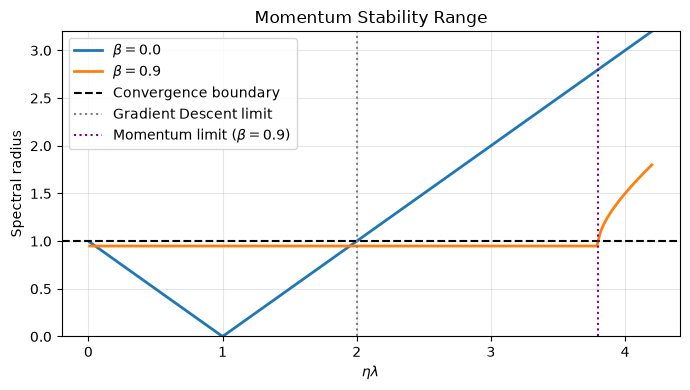

In [6]:
# Momentum의 수렴은 transition matrix에서
# 가장 큰 eigenvalue magnitude로 결정된다.
#
# spectral_radius < 1: 수렴
# spectral_radius = 1: 수렴 경계
# spectral_radius > 1: 발산

def momentum_spectral_radius(
    learning_rate_times_curvature: float,
    momentum: float,
) -> float:
    # lambda=1, eta=eta*lambda로 놓은
    # 정규화된 transition matrix
    transition_matrix = torch.tensor(
        [
            [
                momentum,
                1.0,
            ],
            [
                -learning_rate_times_curvature * momentum,
                1.0 - learning_rate_times_curvature,
            ],
        ],
        dtype=torch.float32,
    )

    eigenvalues = torch.linalg.eigvals(
        transition_matrix
    )

    return float(
        eigenvalues.abs().max()
    )


eta_lambda_values = torch.linspace(
    0.01,
    4.2,
    steps=400,
)

figure, axis = d2l.plt.subplots(
    figsize=(7, 4),
)

for momentum in [
    0.0,
    0.9,
]:
    spectral_radii = [
        momentum_spectral_radius(
            learning_rate_times_curvature=float(value),
            momentum=momentum,
        )
        for value in eta_lambda_values
    ]

    axis.plot(
        eta_lambda_values.numpy(),
        spectral_radii,
        linewidth=2,
        label=rf"$\beta={momentum}$",
    )

axis.axhline(
    y=1.0,
    color="black",
    linestyle="--",
    label="Convergence boundary",
)

axis.axvline(
    x=2.0,
    color="gray",
    linestyle=":",
    label="Gradient Descent limit",
)

axis.axvline(
    x=3.8,
    color="purple",
    linestyle=":",
    label=r"Momentum limit ($\beta=0.9$)",
)

axis.set_xlabel(r"$\eta\lambda$")
axis.set_ylabel("Spectral radius")
axis.set_title("Momentum Stability Range")
axis.set_ylim(0.0, 3.2)
axis.legend()
axis.grid(alpha=0.3)

figure.tight_layout()
d2l.plt.show()